In [21]:
import pandas as pd
import ast
df = pd.read_csv('../../data/transcript_portfolio_profile.csv')

In [49]:
# 1. informational 제외
df = df[df['offer_type'] != 'informational'].copy()

# 2. 이벤트별 데이터 + 컬럼명 미리 지정
received = df[df['event'] == 'offer received'][['customer_id', 'offer_id', 'time']].rename(columns={'time': 'time_received'})
viewed   = df[df['event'] == 'offer viewed'][['customer_id', 'offer_id', 'time']].rename(columns={'time': 'time_viewed'})
completed = df[df['event'] == 'offer completed'][['customer_id', 'offer_id', 'time']].rename(columns={'time': 'time_completed'})

# time 기준 순번 정리
received = received.sort_values(['customer_id', 'offer_id', 'time_received'])
viewed = viewed.sort_values(['customer_id', 'offer_id', 'time_viewed'])
completed = completed.sort_values(['customer_id', 'offer_id', 'time_completed'])

# 3. 순번 부여 - 동일한 고객 id, offer id를 기준으로 순번을 부여함으로써 recevied -> viewed -> completed별 순서를 명확히 파악하기 위해서
received['seq']  = received.groupby(['customer_id', 'offer_id']).cumcount()
viewed['seq']    = viewed.groupby(['customer_id', 'offer_id']).cumcount()
completed['seq'] = completed.groupby(['customer_id', 'offer_id']).cumcount()

# 4. received → viewed
rv = received.merge(viewed, on=['customer_id', 'offer_id', 'seq'], how='left')

rv['viewed_flag'] = (rv['time_viewed'] >= rv['time_received']).astype(int) # 정상적으로, recevied -> viewed 된 케이스만 전환되었다고 파악
view_rate = rv['viewed_flag'].mean()

# 5. viewed → completed
vc = viewed.merge(completed, on=['customer_id', 'offer_id', 'seq'], how='left')

vc['completed_flag'] = (vc['time_completed'] >= vc['time_viewed']).astype(int)
completion_rate = vc['completed_flag'].mean()

# 6. received → completed
rc = received.merge(completed, on=['customer_id', 'offer_id', 'seq'], how='left')

rc['completed_flag'] = (rc['time_completed'] >= rc['time_received']).astype(int)
rc_rate = rc['completed_flag'].mean()

# 7. 결과 출력
print("received → viewed 전환율:", round(view_rate * 100, 2), "%")
print("viewed → completed 전환율:", round(completion_rate * 100, 2), "%")
print("received → completed 전환율:", round(rc_rate * 100, 2), "%")

received → viewed 전환율: 76.82 %
viewed → completed 전환율: 49.97 %
received → completed 전환율: 54.36 %


### time 활용 기준
time은 절대적인 시계열 정보라기보다, 고객 이벤트 간 상대적 순서와 경과시간을 나타내는 값으로 해석한다.
따라서 본 프로젝트에서는 time을 활용해 퍼널 단계 간 선후관계와 반응 지연 시간을 분석한다.
반면, 특정 요일/시각/월별 시즌성과 같은 캘린더 기반 해석은 제외한다.

### seq를 둔 이유
동일 고객이 동일 오퍼를 여러 번 수신할 수 있으므로, 단순 customer_id와 offer_id만으로는 이벤트를 정확히 연결하기 어렵다.
이에 따라 고객-오퍼 그룹 내 발생 순서를 나타내는 seq를 부여하여 n번째 received와 n번째 viewed/completed를 매칭한다.

### time 조건을 둔 이유
merge 이후에도 논리적으로 viewed가 received보다 먼저 나타나는 비정상 연결이 있을 수 있다.
이를 방지하기 위해 time_viewed >= time_received 조건을 적용해 실제 퍼널 순서를 만족하는 경우만 전환으로 집계한다.

In [48]:
# ----------------------------
# 추가: 전환 여부 컬럼
# ----------------------------
rc['is_converted'] = rc['completed_flag']  # 기존 전환율 계산 컬럼 재사용

# ----------------------------
# 추가: 고객 단위 세그먼트
# ----------------------------
customer_segment = rc.groupby('customer_id').agg(
    converted=('is_converted', 'max')
).reset_index()

# ----------------------------
# 추가: 라벨링 (선택)
# ----------------------------
customer_segment['segment'] = customer_segment['converted'].map({
    1: '전환 고객',
    0: '비전환 고객'
})

customer_segment['segment'].value_counts()

segment
전환 고객     12774
비전환 고객     4154
Name: count, dtype: int64

In [72]:
df['customer_id'].nunique()

16996

In [56]:
received[received['seq'] == 3]

,customer_id,offer_id,time_received,seq
247325,04fa747cd2d841bcaf08f0a64e82bbef,2906b810c7d4411798c6938adc9daaa5,576,3
203692,073fce5708884b30a28b65b3cb15a919,9b98b8c7a33c4b65b9aebfe6a799e6d9,504,3
153585,0ea1f0bb1ba245abbf709b962d326dd7,2906b810c7d4411798c6938adc9daaa5,408,3
245818,1679b7af5a294c6d9ae961232318ad55,0b1e1539f2cc45b7b9fa7c272da2e1d7,576,3
254325,1c8cf4af93464dcaa971cfcffc2cc1e5,2298d6c36e964ae4a3e7e9706d1fb8c2,576,3
204456,281d463f31e74ecaa4451d169868c5d7,2298d6c36e964ae4a3e7e9706d1fb8c2,504,3
245654,2be369a184c5446da2ac9563b36370b9,ae264e3637204a6fb9bb56bc8210ddfd,576,3
205253,2dab8c385a2440b78b432ecb72d68787,2298d6c36e964ae4a3e7e9706d1fb8c2,504,3
254750,2e7dd52a1b9b49dd90f5cd3cd8ad9636,fafdcd668e3743c1bb461111dcafc2a4,576,3
207041,2ea50de315514ccaa5079db4c1ecbc0b,fafdcd668e3743c1bb461111dcafc2a4,504,3


In [69]:
received[received['customer_id'] == 'ea54840ba8a54a098de60d39fc533d51']

,customer_id,offer_id,time_received,seq
122986,ea54840ba8a54a098de60d39fc533d51,2298d6c36e964ae4a3e7e9706d1fb8c2,336,0
162812,ea54840ba8a54a098de60d39fc533d51,2298d6c36e964ae4a3e7e9706d1fb8c2,408,1
213613,ea54840ba8a54a098de60d39fc533d51,2298d6c36e964ae4a3e7e9706d1fb8c2,504,2
257104,ea54840ba8a54a098de60d39fc533d51,2298d6c36e964ae4a3e7e9706d1fb8c2,576,3
65337,ea54840ba8a54a098de60d39fc533d51,ae264e3637204a6fb9bb56bc8210ddfd,168,0


In [70]:
viewed[viewed['customer_id'] == 'ea54840ba8a54a098de60d39fc533d51'] # 같은 고객 id, 오퍼 id에서 viewed 전환율 66%

,customer_id,offer_id,time_viewed,seq
130012,ea54840ba8a54a098de60d39fc533d51,2298d6c36e964ae4a3e7e9706d1fb8c2,342,0
167429,ea54840ba8a54a098de60d39fc533d51,2298d6c36e964ae4a3e7e9706d1fb8c2,408,1
218066,ea54840ba8a54a098de60d39fc533d51,2298d6c36e964ae4a3e7e9706d1fb8c2,504,2
276688,ea54840ba8a54a098de60d39fc533d51,2298d6c36e964ae4a3e7e9706d1fb8c2,606,3
83320,ea54840ba8a54a098de60d39fc533d51,ae264e3637204a6fb9bb56bc8210ddfd,204,0


In [71]:
completed[completed['customer_id'] == 'ea54840ba8a54a098de60d39fc533d51'] # 같은 고객 id, 오퍼 id에서 completed 전환율 0%

,customer_id,offer_id,time_completed,seq
145293,ea54840ba8a54a098de60d39fc533d51,2298d6c36e964ae4a3e7e9706d1fb8c2,384,0
171028,ea54840ba8a54a098de60d39fc533d51,2298d6c36e964ae4a3e7e9706d1fb8c2,414,1
218068,ea54840ba8a54a098de60d39fc533d51,2298d6c36e964ae4a3e7e9706d1fb8c2,504,2
283502,ea54840ba8a54a098de60d39fc533d51,2298d6c36e964ae4a3e7e9706d1fb8c2,624,3
87046,ea54840ba8a54a098de60d39fc533d51,ae264e3637204a6fb9bb56bc8210ddfd,216,0


In [ ]:
rv.tail(10) # recevied <= viewed 일 때, viewed_flag 값은 1 아니면 0

,customer_id,offer_id,time_received,seq,time_viewed,viewed_flag
61032,392d23b2c958493197f647bedfe4f418,ae264e3637204a6fb9bb56bc8210ddfd,576,1,708.0,1
61033,97ee6e7a12fe4064b260fa48bdd0330f,9b98b8c7a33c4b65b9aebfe6a799e6d9,576,0,NaN,0
61034,bf3069b178fe40d789dd027901bc406b,0b1e1539f2cc45b7b9fa7c272da2e1d7,576,0,NaN,0
61035,76ddbd6576844afe811f1a3c0fbb5bec,9b98b8c7a33c4b65b9aebfe6a799e6d9,576,1,654.0,1
61036,f653cf2d8bba42d0a53c2937ee2e5893,9b98b8c7a33c4b65b9aebfe6a799e6d9,576,0,NaN,0
61037,670626b55bfb4ba39c85b27cc7cca527,0b1e1539f2cc45b7b9fa7c272da2e1d7,576,0,624.0,1
61038,d087c473b4d247ccb0abfef59ba12b0e,ae264e3637204a6fb9bb56bc8210ddfd,576,0,672.0,1
61039,cb23b66c56f64b109d673d5e56574529,2906b810c7d4411798c6938adc9daaa5,576,1,NaN,0
61040,6d5f3a774f3d4714ab0c092238f3a1d7,2298d6c36e964ae4a3e7e9706d1fb8c2,576,0,588.0,1
61041,9dc1421481194dcd9400aec7c9ae6366,ae264e3637204a6fb9bb56bc8210ddfd,576,0,624.0,1


In [ ]:
rc[rc['time_completed'].notna()].tail() # received <= completed 일 때, completed_flag 값은 1 아니면 0

,customer_id,offer_id,time_received,seq,time_completed,completed_flag
61032,392d23b2c958493197f647bedfe4f418,ae264e3637204a6fb9bb56bc8210ddfd,576,1,624.0,1
61036,f653cf2d8bba42d0a53c2937ee2e5893,9b98b8c7a33c4b65b9aebfe6a799e6d9,576,0,630.0,1
61037,670626b55bfb4ba39c85b27cc7cca527,0b1e1539f2cc45b7b9fa7c272da2e1d7,576,0,666.0,1
61038,d087c473b4d247ccb0abfef59ba12b0e,ae264e3637204a6fb9bb56bc8210ddfd,576,0,636.0,1
61041,9dc1421481194dcd9400aec7c9ae6366,ae264e3637204a6fb9bb56bc8210ddfd,576,0,594.0,1


In [11]:
# 날짜형 변환이 필요하면 사용
df['became_member_on'] = pd.to_datetime(df['became_member_on'], errors='coerce')

# ----------------------------
# 1. 이벤트별 테이블 분리
# ----------------------------
# offer completed 이벤트
completed_df = df[df['event'] == 'offer completed'][
    ['customer_id', 'offer_id', 'time', 'event_reward', 'offer_type', 'difficulty', 'duration']
].copy()

completed_df = completed_df.rename(columns={'time': 'completed_time'})

# transaction 이벤트
transaction_df = df[df['event'] == 'transaction'][
    ['customer_id', 'time', 'amount']
].copy()

transaction_df = transaction_df.rename(columns={'time': 'transaction_time'})

# offer received 이벤트 (참고용)
received_df = df[df['event'] == 'offer received'][
    ['customer_id', 'offer_id', 'time']
].copy()

received_df = received_df.rename(columns={'time': 'received_time'})

# ----------------------------
# 2. completed 기준으로 transaction 연결
# ----------------------------
# 같은 고객 기준으로 transaction 붙이기
check_df = completed_df.merge(
    transaction_df,
    on='customer_id',
    how='left'
)

# ----------------------------
# 3. completed 전/동시/후 transaction 여부 확인
# ----------------------------
# 조건 충족 구매로 볼 수 있는 transaction
check_df['tx_before_or_at_completed'] = (
    check_df['transaction_time'] <= check_df['completed_time']
)

# completed 이후 추가 구매
check_df['tx_after_completed'] = (
    check_df['transaction_time'] > check_df['completed_time']
)

# completed와 transaction 시간 차이
check_df['time_diff'] = check_df['transaction_time'] - check_df['completed_time']

# ----------------------------
# 4. completed 단위로 요약
# ----------------------------
summary = check_df.groupby(
    ['customer_id', 'offer_id', 'completed_time'],
    as_index=False
).agg(
    has_tx_before_or_at=('tx_before_or_at_completed', 'max'),
    has_tx_after=('tx_after_completed', 'max'),
    tx_count=('transaction_time', 'count'),
    min_time_diff=('time_diff', 'min'),
    max_time_diff=('time_diff', 'max')
)

# ----------------------------
# 5. 핵심 확인
# ----------------------------
# print("=== completed 요약 샘플 ===")
# print(summary.head())

print("\n=== completed 기준 transaction 존재 패턴 ===")
print(summary[['has_tx_before_or_at', 'has_tx_after']].value_counts())

print("\n=== completed 이전 또는 같은 시점 transaction 존재 비율 ===")
print(summary['has_tx_before_or_at'].value_counts(normalize=True))

# ----------------------------
# 6. completed와 가장 가까운 transaction 보기
# ----------------------------
closest_tx = check_df.copy()
closest_tx['abs_time_diff'] = closest_tx['time_diff'].abs()

closest_tx = closest_tx.sort_values('abs_time_diff').groupby(
    ['customer_id', 'offer_id', 'completed_time'],
    as_index=False
).first()

print("\n=== completed와 가장 가까운 transaction 샘플 ===")

closest_tx[
    ['customer_id', 'offer_id', 'completed_time', 'transaction_time', 'amount', 'time_diff']
].head(10)


=== completed 기준 transaction 존재 패턴 ===
has_tx_before_or_at  has_tx_after
True                 True            29409
                     False            3773
Name: count, dtype: int64

=== completed 이전 또는 같은 시점 transaction 존재 비율 ===
has_tx_before_or_at
True    1.0
Name: proportion, dtype: float64

=== completed와 가장 가까운 transaction 샘플 ===


,customer_id,offer_id,completed_time,transaction_time,amount,time_diff
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,576,10.27,0
1,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,414,414,8.57,0
2,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,528,528,14.11,0
3,0011e0d4e6b944f998e987f904e8c1e5,0b1e1539f2cc45b7b9fa7c272da2e1d7,576,576,22.05,0
4,0011e0d4e6b944f998e987f904e8c1e5,2298d6c36e964ae4a3e7e9706d1fb8c2,252,252,11.93,0
5,0011e0d4e6b944f998e987f904e8c1e5,9b98b8c7a33c4b65b9aebfe6a799e6d9,576,576,22.05,0
6,0020c2b971eb4e9188eac86d93036a77,4d5c57ea9a6940dd891ad53e9dbe8da0,510,510,17.24,0
7,0020c2b971eb4e9188eac86d93036a77,fafdcd668e3743c1bb461111dcafc2a4,54,54,17.63,0
8,0020c2b971eb4e9188eac86d93036a77,fafdcd668e3743c1bb461111dcafc2a4,510,510,17.24,0
9,0020ccbbb6d84e358d3414a3ff76cffd,2298d6c36e964ae4a3e7e9706d1fb8c2,222,222,11.65,0


offer completed는 “조건을 만족하는 구매가 이미 발생한 상태”를 의미한다
따라서 completed는 별도의 행동이 아니라 transaction 이후 발생하는 이벤트
조건 충족 구매는 transaction_time <= completed_time으로 봐야 한다

completed 이후 transaction은 추가 구매(업셀/재방문)를 의미한다
따라서 퍼널과 전환 정의는 아래처럼 분리해야 한다:

[프로모션 효과]
received → viewed → completed

[구매 발생]
received → transaction

[추가 소비]
completed → transaction

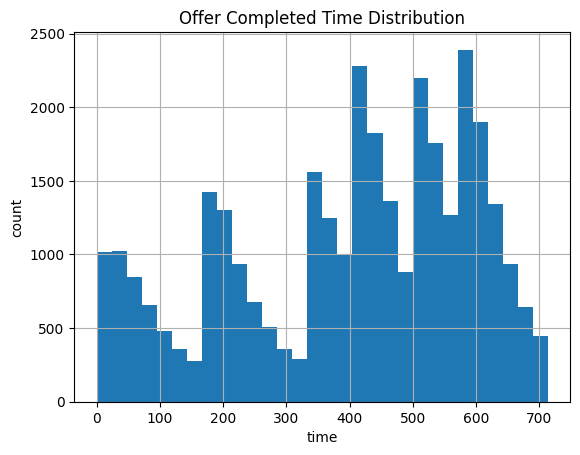

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

df[df['event'] == 'offer completed']['time'].hist(bins = 30)
plt.xlabel('time')
plt.ylabel('count')
plt.title('Offer Completed Time Distribution')
plt.show()

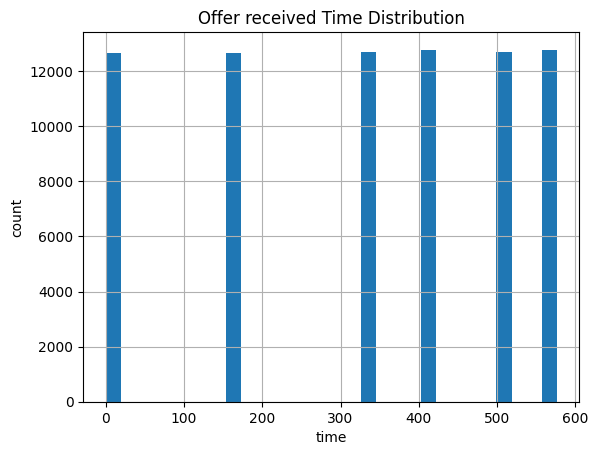

In [28]:
df[df['event'] == 'offer received']['time'].hist(bins = 30)
plt.xlabel('time')
plt.ylabel('count')
plt.title('Offer received Time Distribution')
plt.show()

In [10]:
received[received['customer_id'] == '00116118485d4dfda04fdbaba9a87b5c']

,customer_id,offer_id,time,seq
56475,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,168,0
248112,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,576,1


In [15]:
received['seq'].value_counts()

seq
0    50637
1     9386
2      960
3       56
4        3
Name: count, dtype: int64

received → viewed 전환율: 76.82 %
viewed → completed 전환율: 49.97 %
received → completed 전환율: 54.36 %


In [16]:
view_rate

np.float64(0.7682251564496576)

In [58]:
rv.tail(30)

,customer_id,offer_id,time_received,seq,time_viewed,viewed_flag
61012,1edd693f0c7b49dfa8b33d5e28740151,2906b810c7d4411798c6938adc9daaa5,576,1,NaN,0
61013,3d2ae0a586794fbe881dace3aa2258c6,fafdcd668e3743c1bb461111dcafc2a4,576,0,582.0,1
61014,c15a1ba4aca940b6ba02f74c31985d3d,0b1e1539f2cc45b7b9fa7c272da2e1d7,576,0,618.0,1
61015,efba45d36ae340838b34c74b9ebb1dc2,2298d6c36e964ae4a3e7e9706d1fb8c2,576,1,576.0,1
61016,0b250fe9fab14dac96ba542a572da081,2298d6c36e964ae4a3e7e9706d1fb8c2,576,0,648.0,1
61017,004c5799adbf42868b9cff0396190900,fafdcd668e3743c1bb461111dcafc2a4,576,1,648.0,1
61018,016edb1d1d67477391c5337545a5d98a,fafdcd668e3743c1bb461111dcafc2a4,576,1,600.0,1
61019,e340cbf00a914f0c958577c0af36ed8a,2906b810c7d4411798c6938adc9daaa5,576,0,NaN,0
61020,cec1cdc6b77e41abbdce8903c5522e7e,fafdcd668e3743c1bb461111dcafc2a4,576,1,582.0,1
61021,f19d9482309d4e93ad74935f9e46e44c,fafdcd668e3743c1bb461111dcafc2a4,576,0,582.0,1


segment
전환 고객     12774
비전환 고객     4154
Name: count, dtype: int64

최종 고객(customer_id) 기준으로 전환된 고객인지 아닌 고객인지 판별

한 고객이 여러 오퍼를 받을 수 있기 때문에, 고객 기준으로 max()값을 주어서 1이 나올 경우 전환 고객 판단 가능

In [36]:
df['customer_id'].nunique()

16996

In [49]:
total_customers = df['customer_id'].nunique()
print("전체 고객:", total_customers)

전체 고객: 17000


In [50]:
total_customers = df['customer_id'].nunique()
print("전체 고객:", total_customers)

전체 고객: 17000


In [51]:
received_customers = df[df['event'] == 'offer received']['customer_id'].nunique()
print("offer 받은 고객:", received_customers)

offer 받은 고객: 16994


In [52]:
segment_customers = customer_segment['customer_id'].nunique()
print("세그먼트 고객:", segment_customers)

세그먼트 고객: 16928


In [54]:
missing_customers = set(df['customer_id']) - set(customer_segment['customer_id'])
print("누락 고객 수:", len(missing_customers))

누락 고객 수: 72
